In [2]:
import duckdb
import sys
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pathlib import Path
import polars as pl

In [3]:
from pathlib import Path

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config, data_utils, plots, strategy_utils

TRAIN_PATH = config.TRAIN_PATH

In [4]:
candidate_cols = [

    "active_price",

    "realized_price",

    "mvrv",

    "mvrv_zscore",

    "market_cap",

    "supply_btc"


]

In [5]:
import polars as pl
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("day_utc") >= pl.date(2018, 1, 1))
    .filter(pl.col("metric").is_in(candidate_cols))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

In [6]:
df = df.to_pandas()

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(how="all")

df.isna().mean().sort_values(ascending=False)

date              0.0
active_price      0.0
market_cap        0.0
mvrv              0.0
realized_price    0.0
supply_btc        0.0
price_usd         0.0
dtype: float64

In [7]:
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date").sort_index()

In [8]:
def plot_series(series, title=None):
    plt.figure(figsize=(12, 5))
    plt.plot(series)
    plt.title(title or series.name)
    plt.xlabel("Date")
    plt.ylabel(series.name)
    plt.show()

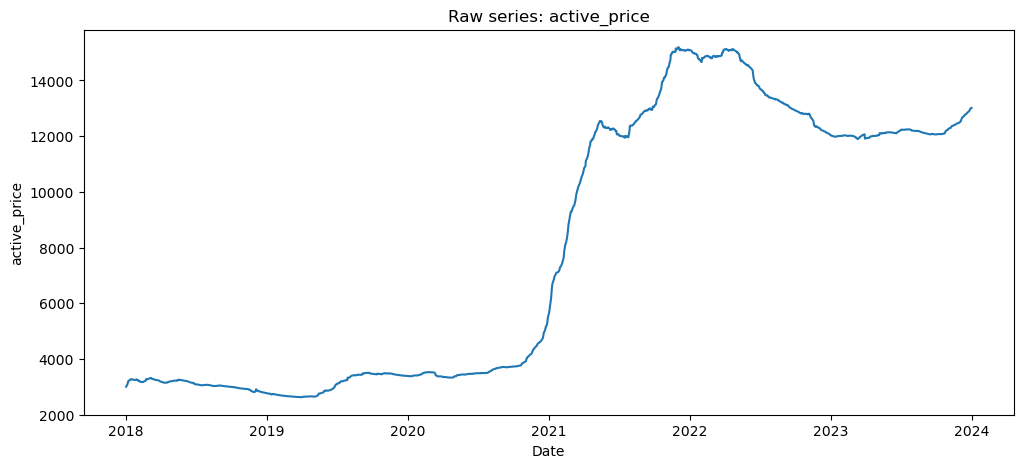

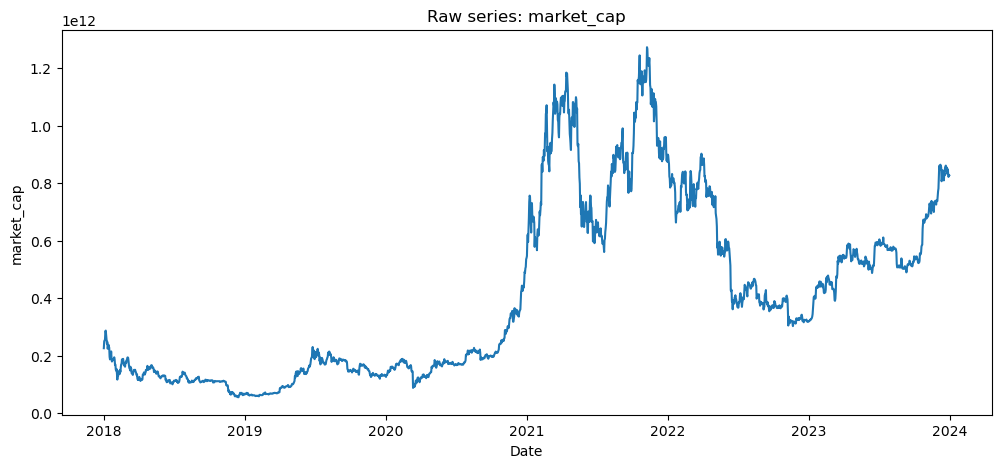

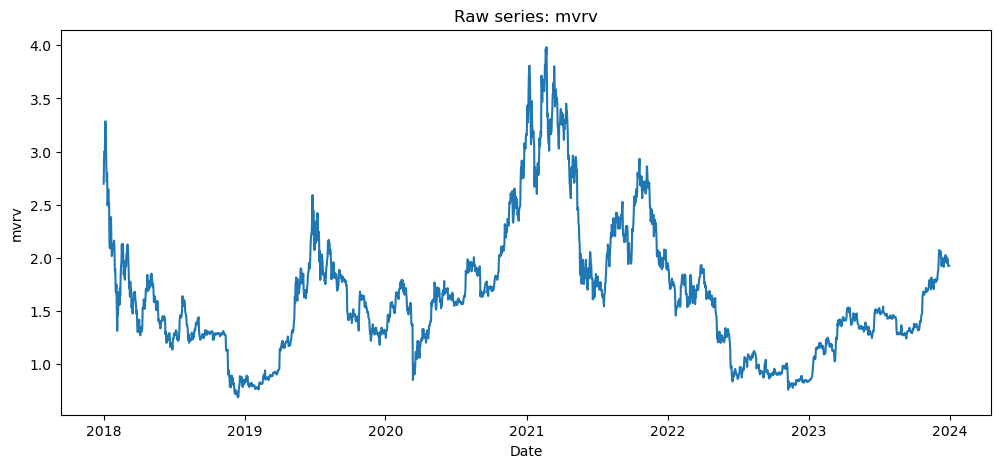

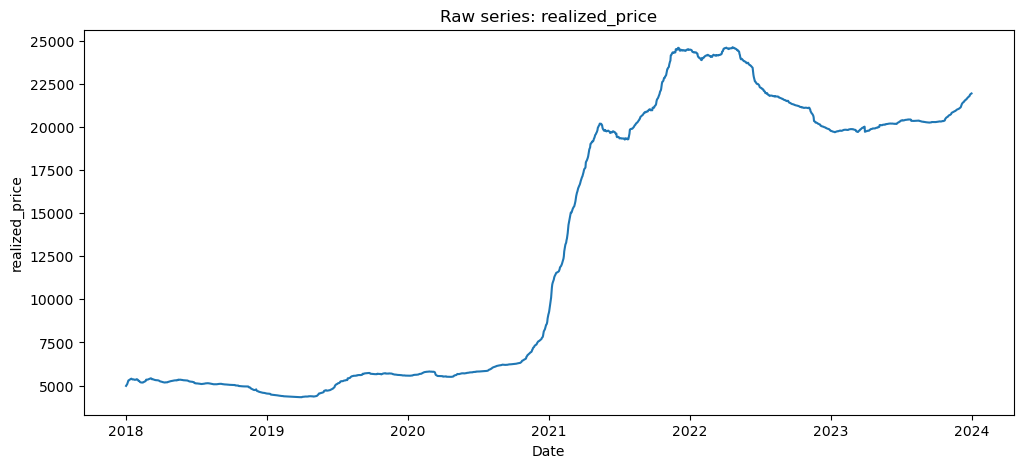

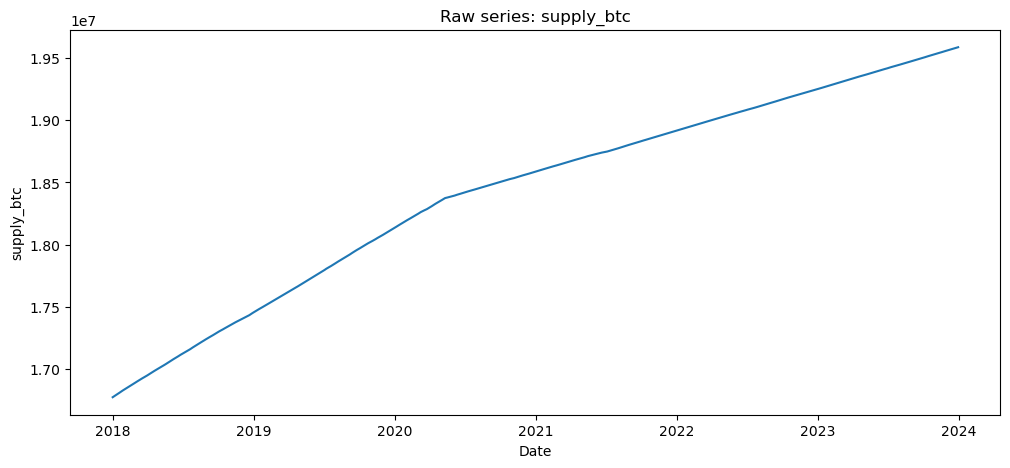

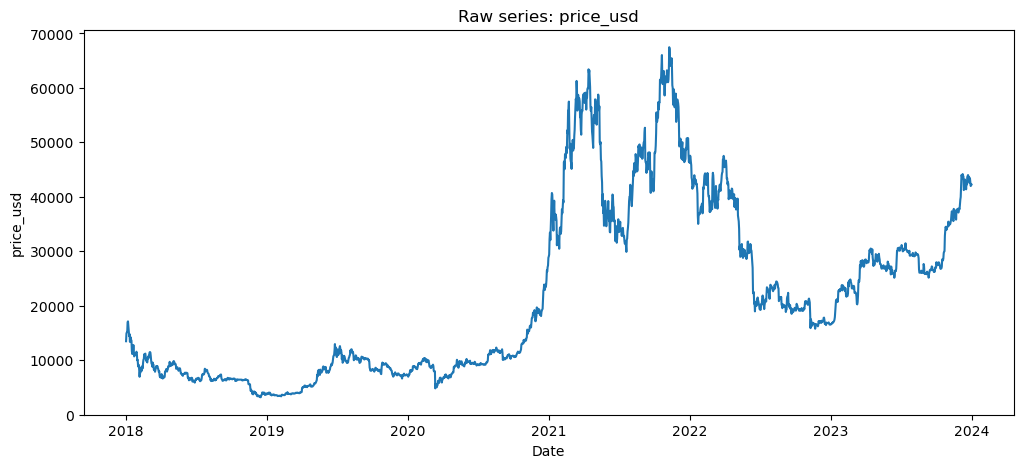

In [9]:
for col in df.columns:
    plot_series(df[col], f"Raw series: {col}")

In [10]:
ts = df.copy()

for col in df.columns:
    ts[f"log_{col}"] = np.log(ts[col].where(ts[col] > 0))
    ts[f"diff_{col}"] = ts[col].diff()
    ts[f"log_return_{col}"] = np.log(ts[col] / ts[col].shift(1))

In [11]:
ts["mvrv_deviation"] = ts["mvrv"] - ts["mvrv"].rolling(365).mean()
ts["mvrv_z_rolling"] = (
    (ts["mvrv"] - ts["mvrv"].rolling(365).mean())
    / ts["mvrv"].rolling(365).std()
)

In [12]:
def stationarity_tests(series, name=None):
    s = series.dropna()
    
    results = {"series": name or series.name}
    
    try:
        adf_result = adfuller(s, autolag="AIC") # ADF pvalue < 0.05 => reject null hypothesis of non-stationarity; conclusion: series is stationary
        results["adf_stat"] = adf_result[0]
        results["adf_pvalue"] = adf_result[1]
    except Exception:
        results["adf_stat"] = np.nan
        results["adf_pvalue"] = np.nan
    
    try:
        kpss_result = kpss(s, regression="c", nlags="auto") # KPSS pvalue > 0.05 => fail to reject null hypothesis of stationarity; conclusion: series is stationary
        results["kpss_stat"] = kpss_result[0]
        results["kpss_pvalue"] = kpss_result[1]
    except Exception:
        results["kpss_stat"] = np.nan
        results["kpss_pvalue"] = np.nan
    
    return results

In [13]:
test_cols = [
    "price_usd",
    "log_price_usd",
    "log_return_price_usd",
    "active_price",
    "log_active_price",
    "log_return_active_price",
    "mvrv",
    "mvrv_deviation",
    "mvrv_z_rolling",
]

stationarity_summary = pd.DataFrame([
    stationarity_tests(ts[col], col)
    for col in test_cols
    if col in ts.columns
])

stationarity_summary

C:\Users\Shruti\AppData\Local\Temp\ipykernel_3060\598866356.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(s, regression="c", nlags="auto") # KPSS pvalue > 0.05 => fail to reject null hypothesis of stationarity; conclusion: series is stationary
C:\Users\Shruti\AppData\Local\Temp\ipykernel_3060\598866356.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(s, regression="c", nlags="auto") # KPSS pvalue > 0.05 => fail to reject null hypothesis of stationarity; conclusion: series is stationary
C:\Users\Shruti\AppData\Local\Temp\ipykernel_3060\598866356.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the

,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
0,price_usd,-1.250029,0.651713,3.727000,0.010000
1,log_price_usd,-0.739511,0.836248,5.088784,0.010000
2,log_return_price_usd,-32.642921,0.000000,0.159539,0.100000
3,active_price,-0.791289,0.821668,6.221928,0.010000
4,log_active_price,-0.675748,0.852932,6.498280,0.010000
5,log_return_active_price,-4.603489,0.000127,0.513194,0.038695
6,mvrv,-2.859914,0.050212,0.751424,0.010000
7,mvrv_deviation,-2.373723,0.149291,0.692806,0.014199
8,mvrv_z_rolling,-2.281830,0.177895,0.502037,0.041208


In [14]:
stationarity_summary[stationarity_summary["adf_pvalue"] < 0.05]

,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
2,log_return_price_usd,-32.642921,0.000000,0.159539,0.100000
5,log_return_active_price,-4.603489,0.000127,0.513194,0.038695


In [15]:
stationarity_summary[stationarity_summary["kpss_pvalue"] > 0.05]

,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
2,log_return_price_usd,-32.642921,0.0,0.159539,0.1


### Only log return of the price is stationary across both tests

In [16]:
def plot_acf_pacf(series, lags=60):
    s = series.dropna()
    
    plot_acf(s, lags=lags)
    plt.title(f"ACF: {series.name}")
    plt.show()
    
    plot_pacf(s, lags=lags, method="ywm")
    plt.title(f"PACF: {series.name}")
    plt.show()

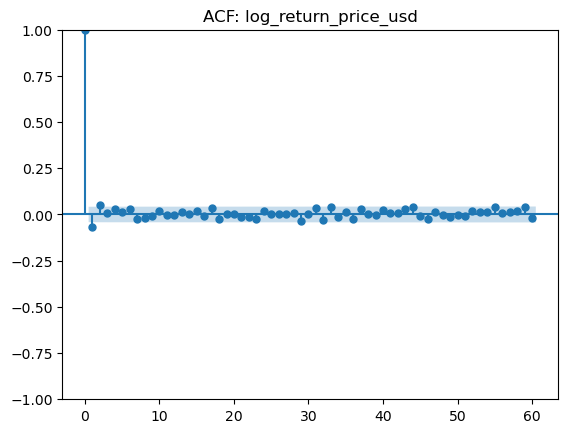

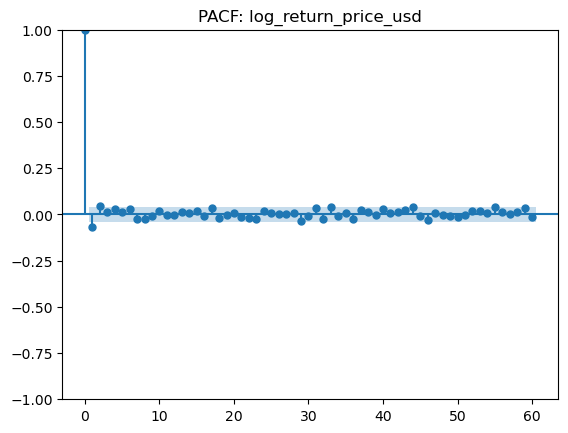

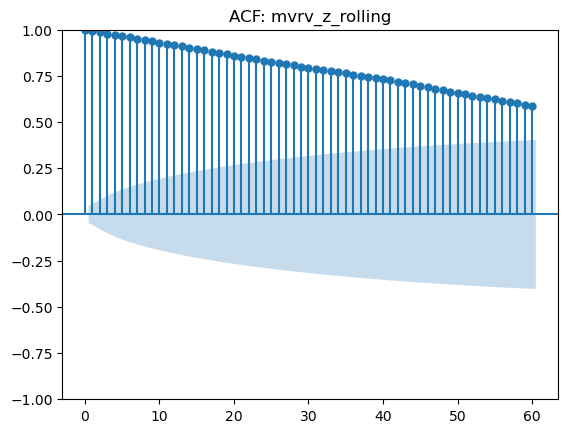

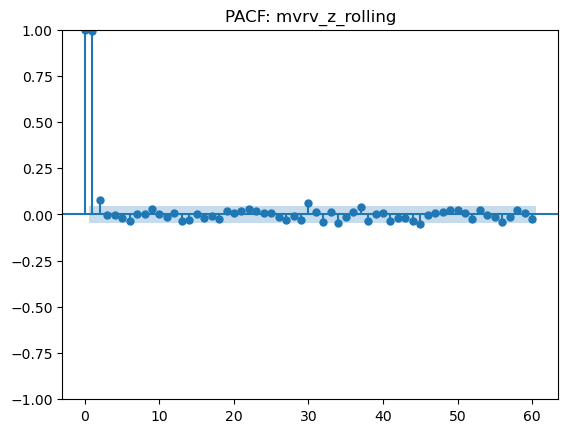

In [17]:
plot_acf_pacf(ts["log_return_price_usd"], lags=60)
plot_acf_pacf(ts["mvrv_z_rolling"], lags=60)

In [18]:
# observed = trend + seasonal + residual
# STL decomposition can help us understand the underlying components of a time series, such as the trend, seasonality, and residuals. 
# This can be useful for identifying patterns and making forecasts.
def stl_decompose(series, period=30, robust=True):
    s = series.dropna()
    model = STL(s, period=period, robust=robust)
    result = model.fit()
    return result

## Check the residual plot over time

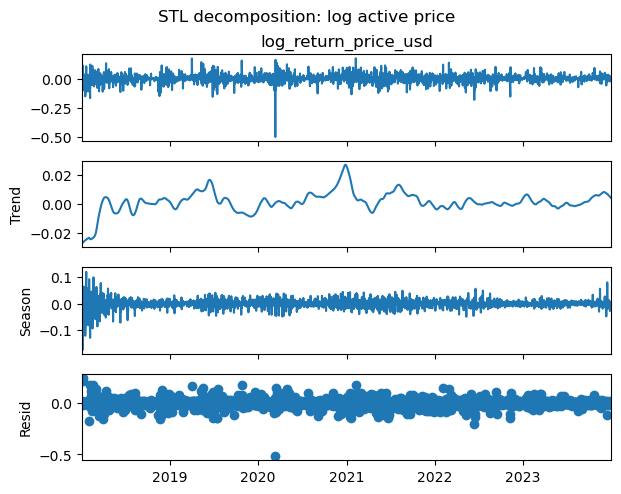

In [19]:
active_stl = stl_decompose(ts["log_return_price_usd"], period=30)

active_stl.plot()
plt.suptitle("STL decomposition: log active price", y=1.02)
plt.show()

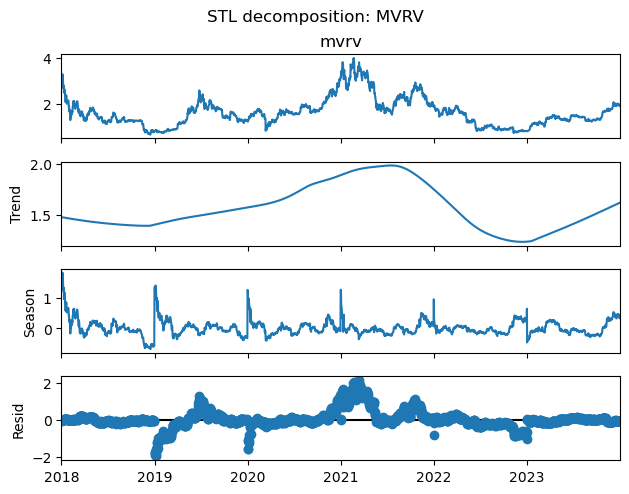

In [20]:
mvrv_stl = stl_decompose(ts["mvrv"], period=365)

mvrv_stl.plot()
plt.suptitle("STL decomposition: MVRV", y=1.02)
plt.show()

In [21]:
# Create detrended / deseasonalized series using the STL decomposition results
# The trend component captures the long-term progression of the series, while the seasonal component captures the repeating patterns. 
# The residual component captures the remaining variability after removing the trend and seasonality. 
# By creating detrended and deseasonalized series, we can analyze the underlying patterns and make forecasts without the influence of trend and seasonality.
def add_stl_features(df, col, period=30):
    result = stl_decompose(df[col], period=period)
    
    out = df.copy()
    out[f"{col}_trend"] = result.trend
    out[f"{col}_seasonal"] = result.seasonal
    out[f"{col}_resid"] = result.resid
    out[f"{col}_detrended"] = df[col] - result.trend
    out[f"{col}_deseasonalized"] = df[col] - result.seasonal
    
    return out

In [22]:
ts = add_stl_features(ts, "log_active_price", period=30)
ts = add_stl_features(ts, "mvrv", period=365)

In [23]:
ts.head()

,active_price,market_cap,mvrv,realized_price,supply_btc,price_usd,log_active_price,diff_active_price,log_return_active_price,log_market_cap,...,log_active_price_trend,log_active_price_seasonal,log_active_price_resid,log_active_price_detrended,log_active_price_deseasonalized,mvrv_trend,mvrv_seasonal,mvrv_resid,mvrv_detrended,mvrv_deseasonalized
date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,3006.298120,2.259147e+11,2.697882,4982.419500,1.677629e+07,13466.31,8.008465,NaN,NaN,26.143423,...,8.076849,-0.018303,-0.050081,-0.068384,8.026768,1.482824,1.221073,-0.006015,1.215058,1.476809
2018-01-02,3029.016372,2.497990e+11,2.944071,5017.076367,1.677842e+07,14888.11,8.015993,22.718251,0.007528,26.243922,...,8.077204,-0.007009,-0.054203,-0.061211,8.023002,1.482387,1.492714,-0.031029,1.461685,1.451358
2018-01-03,3047.247163,2.533526e+11,3.001065,5046.828811,1.678039e+07,15098.14,8.021994,18.230791,0.006001,26.258048,...,8.077560,-0.018553,-0.037013,-0.055566,8.040547,1.481951,1.525150,-0.006036,1.519114,1.475915
2018-01-04,3072.132815,2.541706e+11,2.985702,5087.183014,1.678249e+07,15144.99,8.030127,24.885652,0.008133,26.261271,...,8.077916,-0.021151,-0.026638,-0.047788,8.051278,1.481516,1.510233,-0.006047,1.504186,1.475469
2018-01-05,3119.591494,2.846614e+11,3.285019,5161.573986,1.678427e+07,16960.01,8.045457,47.458679,0.015330,26.374566,...,8.078272,-0.015026,-0.017788,-0.032814,8.060484,1.481081,1.809995,-0.006057,1.803938,1.475024


The residual/detrended component may be more useful than the raw metric. It tells us when the metric is unusually high or low relative to its own structure

In [24]:
def diagnostic_tests(series, lags=20):
    s = series.dropna()
    
    lb = acorr_ljungbox(s, lags=[lags], return_df=True)
    arch = het_arch(s)
    
    return {
        "series": series.name,
        "ljung_box_pvalue": lb["lb_pvalue"].iloc[0],
        "arch_stat": arch[0],
        "arch_pvalue": arch[1],
    }

Ljung-Box p-value < 0.05 → autocorrelation exists
ARCH p-value < 0.05      → volatility clustering exists

In [25]:
diagnostic_summary = pd.DataFrame([
    diagnostic_tests(ts[col])
    for col in [
        "log_return_price_usd",
        "mvrv_z_rolling",
        "log_active_price_resid",
        "mvrv_resid",
    ]
    if col in ts.columns
])

diagnostic_summary

,series,ljung_box_pvalue,arch_stat,arch_pvalue
0,log_return_price_usd,0.078302,40.372106,0.000015
1,mvrv_z_rolling,0.000000,1693.648316,0.000000
2,log_active_price_resid,0.000000,2039.572602,0.000000
3,mvrv_resid,0.000000,1997.447856,0.000000


```
Market Data
    ↓
Time Series Diagnostics
    ↓
GARCH Volatility Estimation
    ↓
Feature Construction
    ↓
Hidden Markov Regime Detection
    ↓
Regime-Aware DCA Signal
    ↓
Stacksats Backtesting
```

In [26]:
from arch import arch_model

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler

In [27]:
model_df = ts.copy()

model_df["btc_log_return"] = np.log(
    model_df["price_usd"] / model_df["price_usd"].shift(1)
)

model_df["btc_return_pct"] = model_df["btc_log_return"] * 100

model_df = model_df.replace([np.inf, -np.inf], np.nan)

GARCH is used to analyze and forecast volatility in time-series data, particularly in financial markets. It helps investors and risk managers estimate how much the price of an asset is likely to fluctuate

GARCH works better when returns are expressed in percentage terms rather than tiny decimals.

In [28]:
returns = model_df["btc_return_pct"].dropna()

garch = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_result = garch.fit(disp="off")

print(garch_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:               btc_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5576.05
Distribution:      Standardized Student's t   AIC:                           11162.1
Method:                  Maximum Likelihood   BIC:                           11190.6
                                              No. Observations:                 2190
Date:                      Tue, Jun 02 2026   Df Residuals:                     2189
Time:                              17:44:54   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

mean="Constant" → returns have weak predictability, so simple mean is enough
vol="GARCH"     → ARCH effects exist, so variance is time-varying
p=1, q=1        → standard baseline volatility model
dist="t"        → crypto returns are fat-tailed, so Student-t is better than Gaussian

In [29]:
model_df.loc[returns.index, "garch_volatility"] = garch_result.conditional_volatility

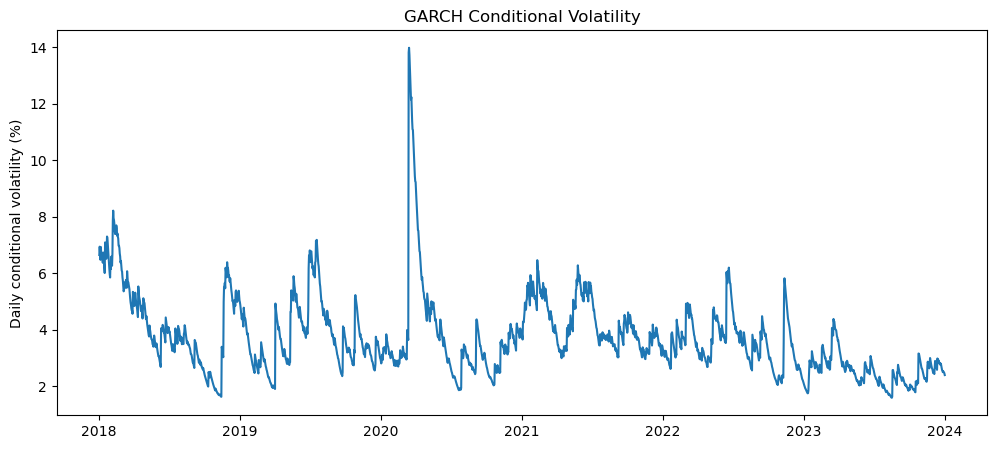

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(model_df["garch_volatility"])
plt.title("GARCH Conditional Volatility")
plt.ylabel("Daily conditional volatility (%)")
plt.show()

* Spikes = high-risk regimes
* Low values = calmer accumulation periods

`HMM implementation`

return          → short-term direction
volatility      → risk regime
mvrv_z          → valuation regime
price_vs_active → recent participant profit/loss state

In [31]:
model_df.columns

Index(['active_price', 'market_cap', 'mvrv', 'realized_price', 'supply_btc',
       'price_usd', 'log_active_price', 'diff_active_price',
       'log_return_active_price', 'log_market_cap', 'diff_market_cap',
       'log_return_market_cap', 'log_mvrv', 'diff_mvrv', 'log_return_mvrv',
       'log_realized_price', 'diff_realized_price',
       'log_return_realized_price', 'log_supply_btc', 'diff_supply_btc',
       'log_return_supply_btc', 'log_price_usd', 'diff_price_usd',
       'log_return_price_usd', 'mvrv_deviation', 'mvrv_z_rolling',
       'log_active_price_trend', 'log_active_price_seasonal',
       'log_active_price_resid', 'log_active_price_detrended',
       'log_active_price_deseasonalized', 'mvrv_trend', 'mvrv_seasonal',
       'mvrv_resid', 'mvrv_detrended', 'mvrv_deseasonalized', 'btc_log_return',
       'btc_return_pct', 'garch_volatility'],
      dtype='str')

In [32]:
hmm_features = pd.DataFrame(index=model_df.index)

hmm_features["return"] = model_df["btc_log_return"]
hmm_features["volatility"] = model_df["garch_volatility"]
hmm_features["mvrv_z"] = model_df["mvrv_z_rolling"]
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

hmm_features = hmm_features.replace([np.inf, -np.inf], np.nan).dropna()

In [33]:
scaler = StandardScaler()

X = scaler.fit_transform(hmm_features)

State 1 → accumulation / undervalued
State 2 → neutral / transition
State 3 → overheated / high-risk

In [34]:
from stacksats.runner import StrategyRunner
from stacksats import BacktestConfig, ComparisonConfig
from stacksats.strategies import UniformStrategy
from stacksats import BaseStrategy
from stacksats import DayState, ExportConfig

uniform_strategy = UniformStrategy()

config = BacktestConfig(
    start_date="2019-01-01",
    end_date="2024-01-01"
)

runner = StrategyRunner()


In [38]:
# returns -> Short term price movement, more stable than raw price
# volatility -> measure of risk, can indicate market uncertainty
# mvrv_z -> valuation metric, can indicate if market is overvalued or undervalued
# price_vs_active -> market demand vs supply, can indicate buying pressure/holder profitability

In [39]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm.fit(X)

regime_probs = hmm.predict_proba(X)

c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [40]:
hmm_features["regime"] = hmm.predict(X)

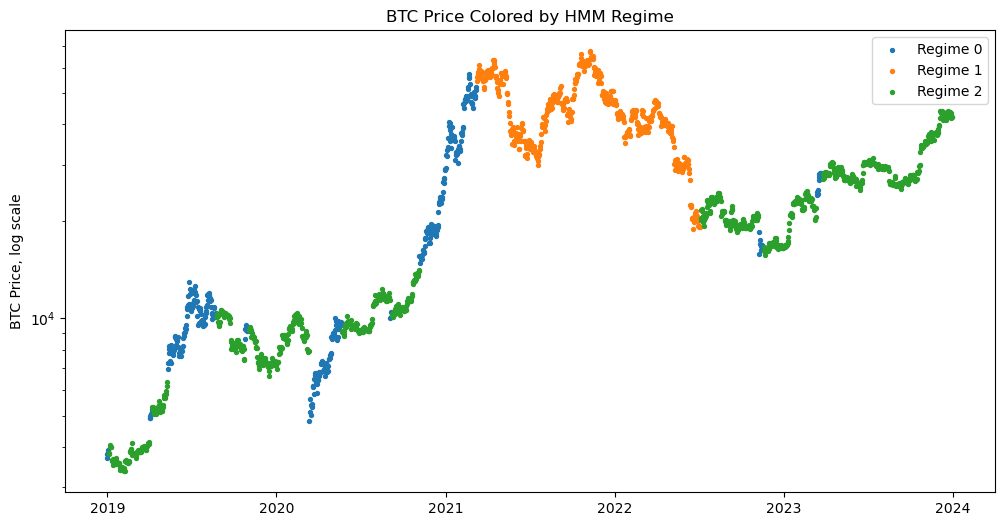

In [41]:
plot_df = model_df.join(hmm_features["regime"], how="left")

plt.figure(figsize=(12, 6))

for regime in sorted(plot_df["regime"].dropna().unique()):
    subset = plot_df[plot_df["regime"] == regime]
    plt.scatter(
        subset.index,
        subset["price_usd"],
        s=8,
        label=f"Regime {int(regime)}"
    )

plt.yscale("log")
plt.title("BTC Price Colored by HMM Regime")
plt.ylabel("BTC Price, log scale")
plt.legend()
plt.show()

In [42]:
# This gives us the probability of being in each regime for each day, 
# which we can use to create a more nuanced allocation strategy that weights the regimes by their probabilities instead of making hard assignments.
# Markets don't just switch from "overheated" to "accumulation" overnight - there are often transition periods where the probabilities are more mixed.

In [43]:
for i in range(hmm.n_components):
    hmm_features[f"regime_prob_{i}"] = regime_probs[:, i]

In [44]:
prob_cols = [f"regime_prob_{i}" for i in range(hmm.n_components)]

plot_df = model_df.join(
    hmm_features[["regime"] + prob_cols],
    how="left"
)

plot_df = plot_df.rename(columns={"regime": "hmm_regime"})

In [45]:
regime_summary = (
    hmm_features
    .groupby("regime")
    .mean()
)

regime_summary

,return,volatility,mvrv_z,price_vs_active,regime_prob_0,regime_prob_1,regime_prob_2
regime,,,,,,,
0,0.006480,5.216007,1.379440,2.420407,0.979914,0.002754,0.017332
1,-0.001964,3.954175,-0.617299,2.312177,0.000783,0.997434,0.001783
2,0.001105,2.880455,0.251039,1.248468,0.005578,0.000239,0.994183


In [46]:
# Based on the regime summary, we can assign labels to the regimes.
# We assign based on mvrv_z_rolling because it is a valuation metric, which is often the most important factor for long-term accumulation strategies.
# Using just return or volatility could lead to assigning the regimes to mostly
# calm or volatile periods but might miss out on valuation context which mvrv_z_rolling provides, that might not be ideal for a long-term accumulation strategy.
# This way the model can distinguish between periods that are undervalued but volatile (good buying opportunities) vs 
# overvalued and volatile (bad buying opportunities), which is crucial for a strategy focused on accumulating more BTC over time.
euphoric_regime = 0
accumulation_regime = 1
neutral_regime = 2

In [47]:
regime_multiplier = {
    0.0: 0.50,  # high risk
    1.0: 1.75,  # undervalued accumulation
    2.0: 1.00,  # neutral
}

# The next cell assigns a regime weight based on a combination of the regime we are in and its multiplier
# So if we are in an undervalued regime (1), the multiplier is 1.75, which means we want to buy 75% more than our baseline allocation.
# If we are in an overheated regime (0), the multiplier is 0.5, which means we want to buy 50% less than our baseline allocation.
# If we are in a neutral regime (2), the multiplier is 1.0, which means we want to buy the same as our baseline allocation.

In [48]:
plot_df["prob_regime_weight"] = (
    plot_df[f"regime_prob_{euphoric_regime}"] * regime_multiplier[euphoric_regime]
    + plot_df[f"regime_prob_{accumulation_regime}"] * regime_multiplier[accumulation_regime]
    + plot_df[f"regime_prob_{neutral_regime}"] * regime_multiplier[neutral_regime]
)

In [49]:
#mvrv_z = +1.0 → 0, not cheap
#mvrv_z = -1.0 → 1, moderately cheap
#mvrv_z = -2.0 → 2, very cheap
#0 = not undervalued
#1 = strongly undervalued
plot_df["valuation_signal"] = (
    -plot_df["mvrv_z_rolling"]
).clip(lower=0)

In [50]:
# Based on how undervalued the market is, we can create a valuation signal where 0 means not undervalued and 2 means very undervalued.
# We clip it to prevent a big boost when negative (very overvalued). We only want to boost buying when the market is undervalued, not when it's overvalued.
# We will then adjust accumulation intensity based on valuation severity

In [51]:
# valuation signal has range [0, 2], we can create an adjustment that gives a multiplier of 1.0x when normal (we buy at DCA levels)
# 1.5x when moderately undervalued, and 2.0x when very undervalued

In [52]:
plot_df["valuation_adjustment"] = (
    1 + 0.50 * plot_df["valuation_signal"]
)

In [53]:
# We get the rolling volatility from the GARCH model, which gives us a measure of how volatile the market is on each day.
# We can then create a volatility adjustment that reduces our buying when volatility is high and the market is overvalued, 
# since high volatility can indicate increased risk and uncertainty in the market.
# and increases our buying when volatility is high but the market is undervalued, since that could indicate a good buying opportunity 

In [54]:
plot_df["volatility_percentile"] = (
    plot_df["garch_volatility"]
    .rolling(365)
    .rank(pct=True)
)

In [55]:
# Cheap + high volatility     → panic opportunity → buy more
# Expensive + high volatility → risk/euphoria     → buy slightly less

plot_df["volatility_adjustment"] = 1.0

cheap_market = plot_df["valuation_signal"] > 0.5

plot_df.loc[cheap_market, "volatility_adjustment"] = (
    1 + 0.40 * plot_df.loc[cheap_market, "volatility_percentile"]
)

plot_df.loc[~cheap_market, "volatility_adjustment"] = (
    1 - 0.20 * plot_df.loc[~cheap_market, "volatility_percentile"]
)

In [56]:
# This is a long term trend filter. It gives an indication of broader market structure (whether the market is in a long term uptrend or downtrend) 
# which can help avoid buying too much in a prolonged bear market.

In [57]:
plot_df["price_200d_ma"] = (
    plot_df["price_usd"]
    .rolling(200)
    .mean()
)

plot_df["trend_signal"] = (
    plot_df["price_usd"] > plot_df["price_200d_ma"]
).astype(float)

plot_df["trend_adjustment"] = np.where(
    plot_df["trend_signal"] == 1,
    1.05,
    0.95
)


# Positive trend → slightly more confidence
# Negative trend → slightly more caution

In [58]:
# final weight =
#     regime belief
#   × valuation opportunity
#   × volatility context
#   × trend context


# HMM regime probabilities → what market state are we probably in?
# MVRV valuation           → is BTC cheap or expensive?
# GARCH volatility         → is stress high or low?
# Trend filter             → is the broader price structure supportive (up or down)?

In [59]:
plot_df["hmm_garch_v2_allocation_weight"] = (
    plot_df["prob_regime_weight"]
    * plot_df["valuation_adjustment"]
    * plot_df["volatility_adjustment"]
    * plot_df["trend_adjustment"]
).clip(0.50, 2.50)

In [60]:
# Smooth the allocation weight with a 7-day rolling average to avoid too much day-to-day noise in the allocation.

In [61]:
plot_df["hmm_garch_v2_allocation_weight"] = (
    plot_df["hmm_garch_v2_allocation_weight"]
    .rolling(7)
    .mean()
    .fillna(plot_df["hmm_garch_v2_allocation_weight"])
)

In [62]:
signal_cols = [
    "hmm_garch_v2_allocation_weight",
    "prob_regime_weight",
    "valuation_adjustment",
    "volatility_adjustment",
    "trend_adjustment",
    "hmm_regime",
]

signals_pd = (
    plot_df
    .reset_index()
    [["date"] + signal_cols]
)

btc_df = (
    df.reset_index()
    .merge(signals_pd, on="date", how="left")
)

btc_df["hmm_garch_v2_allocation_weight"] = (
    btc_df["hmm_garch_v2_allocation_weight"]
    .fillna(1.0)
)

In [63]:
import polars as pl

btc_df_pl = pl.from_pandas(btc_df).with_columns(
    pl.col("date").cast(pl.Date)
)

In [64]:
btc_df_pl.select([
    pl.col("hmm_garch_v2_allocation_weight").mean().alias("mean_signal"),
    pl.col("hmm_garch_v2_allocation_weight").min().alias("min_signal"),
    pl.col("hmm_garch_v2_allocation_weight").max().alias("max_signal"),
    pl.col("hmm_garch_v2_allocation_weight").std().alias("std_signal"),
])

mean_signal,min_signal,max_signal,std_signal
f64,f64,f64,f64
1.292025,0.5,2.5,0.617915


In [65]:
class HMMGARCHV2Strategy(BaseStrategy):
    strategy_id = "hmm-garch-v2"
    version = "1.0.0"

    def __init__(self, signal_df, min_weight=0.50, max_weight=2.50):
        self.min_weight = min_weight
        self.max_weight = max_weight

        self.signal_df = (
            signal_df
            .select(["date", "hmm_garch_v2_allocation_weight"])
            .with_columns(pl.col("date").cast(pl.Date))
        )

    def propose_weight(self, state):
        current_date = (
            state.features
            .select("date")
            .tail(1)
            .item()
        )

        signal_row = self.signal_df.filter(
            pl.col("date") == current_date
        )

        if signal_row.is_empty():
            signal = 1.0
        else:
            signal = (
                signal_row
                .select("hmm_garch_v2_allocation_weight")
                .item()
            )

        if signal is None:
            signal = 1.0

        signal = float(signal)
        signal = max(self.min_weight, min(signal, self.max_weight))

        return state.uniform_weight * signal

In [66]:
hmm2 = HMMGARCHV2Strategy(signal_df=btc_df_pl)

In [67]:
start_date = btc_df_pl.select(pl.col("date").min()).item()
end_date = btc_df_pl.select(pl.col("date").max()).item()

print(f"Backtesting from {start_date} to {end_date}")

Backtesting from 2018-01-01 to 2023-12-31


In [68]:
hmm2_bt = runner.backtest(
    hmm2,
    config=BacktestConfig(
        start_date=str(start_date),
        end_date=str(end_date),
    ),
    btc_df=btc_df_pl,
)
hmm2_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,14736.064632,34.766505,34.766505,2.2027e-13
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,14787.64918,34.968165,34.968165,1.9895e-13
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,14839.606896,35.171063,35.171284,0.000221
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,14893.47666,35.383081,35.381878,-0.001202
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,14947.473195,35.592341,35.592968,0.000627
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,3692.53567,36.43953,37.676724,1.237194
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,3678.03289,36.172452,37.294241,1.121789
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,3663.806764,35.910124,36.919055,1.008931


In [69]:
hmm2_bt.summary()

'Score: 45.84% | Win Rate: 52.44% | Exp-Decay Percentile: 39.25% | Uniform Exp-Decay: 37.29% | Exp-Decay Multiple: 1.052x | Windows: 1827'

In [ ]:
from stacksats import UniformStrategy, ComparisonConfig

hmm_yearly = []
uniform_yearly = []
uniform_strategy = UniformStrategy()

for year in range(2018, 2024):
    hmm = strategy_utils.export_one_year(hmm2, btc_df_pl, year, runner)
    if hmm is not None:
        hmm_yearly.append(hmm)

    uniform_result = strategy_utils.export_one_year(uniform_strategy, btc_df_pl, year, runner)
    if uniform_result is not None:
        uniform_yearly.append(uniform_result)

print("HMM-GARCH valid yearly exports:", len(hmm_yearly))
print("Uniform valid yearly exports:", len(uniform_yearly))
if not hmm_yearly:
    raise ValueError("No valid HMM-GARCH exports were produced.")

if not uniform_yearly:
    raise ValueError("No valid Uniform exports were produced.")

hmm_all = pl.concat(hmm_yearly).rename({"weight": "hmm_weight_raw"})
uniform_all = pl.concat(uniform_yearly).rename({"weight": "baseline_weight_raw"})

print("HMM-GARCH combined rows:", hmm_all.height)
print("Uniform combined rows:", uniform_all.height)
merged = (
    hmm_all
    .select(["date", "price_usd", "hmm_weight_raw"])
    .join(
        uniform_all.select(["date", "baseline_weight_raw"]),
        on="date",
        how="inner"
    )
    .sort("date")
)

print("Merged rows:", merged.height)

merged.head()
hmm_sum = merged["hmm_weight_raw"].sum()
uniform_sum = merged["baseline_weight_raw"].sum()

merged = merged.with_columns([
    (pl.col("hmm_weight_raw") / hmm_sum).alias("hmm_weight"),
    (pl.col("baseline_weight_raw") / uniform_sum).alias("baseline_weight"),
])

print("HMM-GARCH normalized weight sum:", merged["hmm_weight"].sum())
print("Uniform normalized weight sum:", merged["baseline_weight"].sum())
total_budget_usd = 1000.0

merged = merged.with_columns([
    (pl.col("hmm_weight") * total_budget_usd).alias("hmm_usd"),
    (pl.col("baseline_weight") * total_budget_usd).alias("baseline_usd"),
])

merged = merged.with_columns([
    (pl.col("hmm_usd") / pl.col("price_usd")).alias("btc_accum_hmm"),
    (pl.col("baseline_usd") / pl.col("price_usd")).alias("btc_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("btc_accum_hmm") * 100_000_000).alias("sats_accum_hmm"),
    (pl.col("btc_accum_baseline") * 100_000_000).alias("sats_accum_baseline"),
])

merged = merged.with_columns([
    (pl.col("sats_accum_hmm") / pl.col("hmm_usd")).alias("sats_per_dollar_hmm"),
    (pl.col("sats_accum_baseline") / pl.col("baseline_usd")).alias("sats_per_dollar_baseline"),
])

total_dynamic_btc = merged["btc_accum_hmm"].sum()
total_baseline_btc = merged["btc_accum_baseline"].sum()

sats_per_dollar_dynamic = (total_dynamic_btc / total_budget_usd) * 100_000_000
sats_per_dollar_baseline = (total_baseline_btc / total_budget_usd) * 100_000_000

pct_diff_vs_baseline = (
    (total_dynamic_btc - total_baseline_btc) / total_baseline_btc
) * 100

performance_label = "better" if pct_diff_vs_baseline > 0 else "worse"

print(f"Total BTC accumulated, hmm: {total_dynamic_btc:.6f}")
print(f"Total BTC accumulated, Uniform: {total_baseline_btc:.6f}")
print(f"Sats per dollar, hmm: {sats_per_dollar_dynamic:.2f}")
print(f"Sats per dollar, Uniform: {sats_per_dollar_baseline:.2f}")
print(f"hmm performed {abs(pct_diff_vs_baseline):.2f}% {performance_label} than Uniform")
def assign_cycle_label(date):
    for cycle in plots.calendar_cycles:
        start = pd.to_datetime(cycle["start"])
        end = pd.to_datetime(cycle["end"])
        if start <= date <= end:
            return cycle["label"]
    return "Outside cycle"


plot_df = merged.to_pandas()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year
plot_df["cycle_label"] = plot_df["date"].apply(assign_cycle_label)

plot_df.head()
top_buy_points_list = []

for year, year_df in plot_df.groupby("year"):
    threshold = year_df["hmm_weight"].quantile(0.90)

    top_year_df = year_df[year_df["hmm_weight"] >= threshold].copy()
    top_year_df["top_buy_threshold_year"] = threshold

    top_buy_points_list.append(top_year_df)

top_buy_points = pd.concat(top_buy_points_list, ignore_index=True)

top_buy_points = top_buy_points.sort_values(
    ["year", "hmm_weight"],
    ascending=[True, False]
)

print("Top buy points:", len(top_buy_points))
top_buy_points[["date", "year", "price_usd", "hmm_weight", "top_buy_threshold_year"]].head()

cols = plots.StrategyColumns(
    weight="hmm_weight",
    spd="sats_per_dollar_hmm",
    sats_accum="sats_accum_hmm",
)

# Full period
full_plot = plots.plot_strategy_full_period(plot_df, cols, "HMM GARCH Strategy", ("2018-01-01", "2023-12-31"))
plt.show()


2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
HMM-GARCH valid yearly exports: 6
Uniform valid yearly exports: 6
HMM-GARCH combined rows: 2190
Uniform combined rows: 2190
Merged rows: 2190
HMM-GARCH normalized weight sum: 1.0
Uniform normalized weight sum: 1.0
Total BTC accumulated, hmm: 0.086623
Total BTC accumulated, Uniform: 0.084188
Sats per dollar, hmm: 8662.27
Sats per dollar, Uniform: 8418.79
hmm performed 2.89% better than Uniform
Top buy points: 668


In [71]:
config = ExportConfig(
            range_start=str(start_date),
            range_end=str(end_date)
        )
strategy_export2 = runner.export(hmm2, config, btc_df=btc_df_pl)
strategy_export2.to_dataframe()

start_date,end_date,day_index,date,price_usd,weight
datetime[μs],datetime[μs],f64,datetime[μs],f64,f64
2018-01-01 00:00:00,2018-12-31 00:00:00,0.0,2018-01-01 00:00:00,13466.31,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,1.0,2018-01-02 00:00:00,14888.11,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,2.0,2018-01-03 00:00:00,15098.14,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,3.0,2018-01-04 00:00:00,15144.99,0.00274
2018-01-01 00:00:00,2018-12-31 00:00:00,4.0,2018-01-05 00:00:00,16960.01,0.00274
…,…,…,…,…,…
2023-01-01 00:00:00,2023-12-31 00:00:00,360.0,2023-12-27 00:00:00,43337.18,0.002538
2023-01-01 00:00:00,2023-12-31 00:00:00,361.0,2023-12-28 00:00:00,42577.15,0.00256
2023-01-01 00:00:00,2023-12-31 00:00:00,362.0,2023-12-29 00:00:00,41965.03,0.002579
